In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Conv2D, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam
from time import *
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

import pandas as pd
import os

import matplotlib.pyplot as plt

print(tf.__version__)

2.17.0


# Hasil Prediksi Model

Input Shape: [  1 224 224   3]
Input Type: <class 'numpy.float32'>
Output Shape: [ 1 13]
Output Type: <class 'numpy.float32'>
Found 260 images belonging to 13 classes.


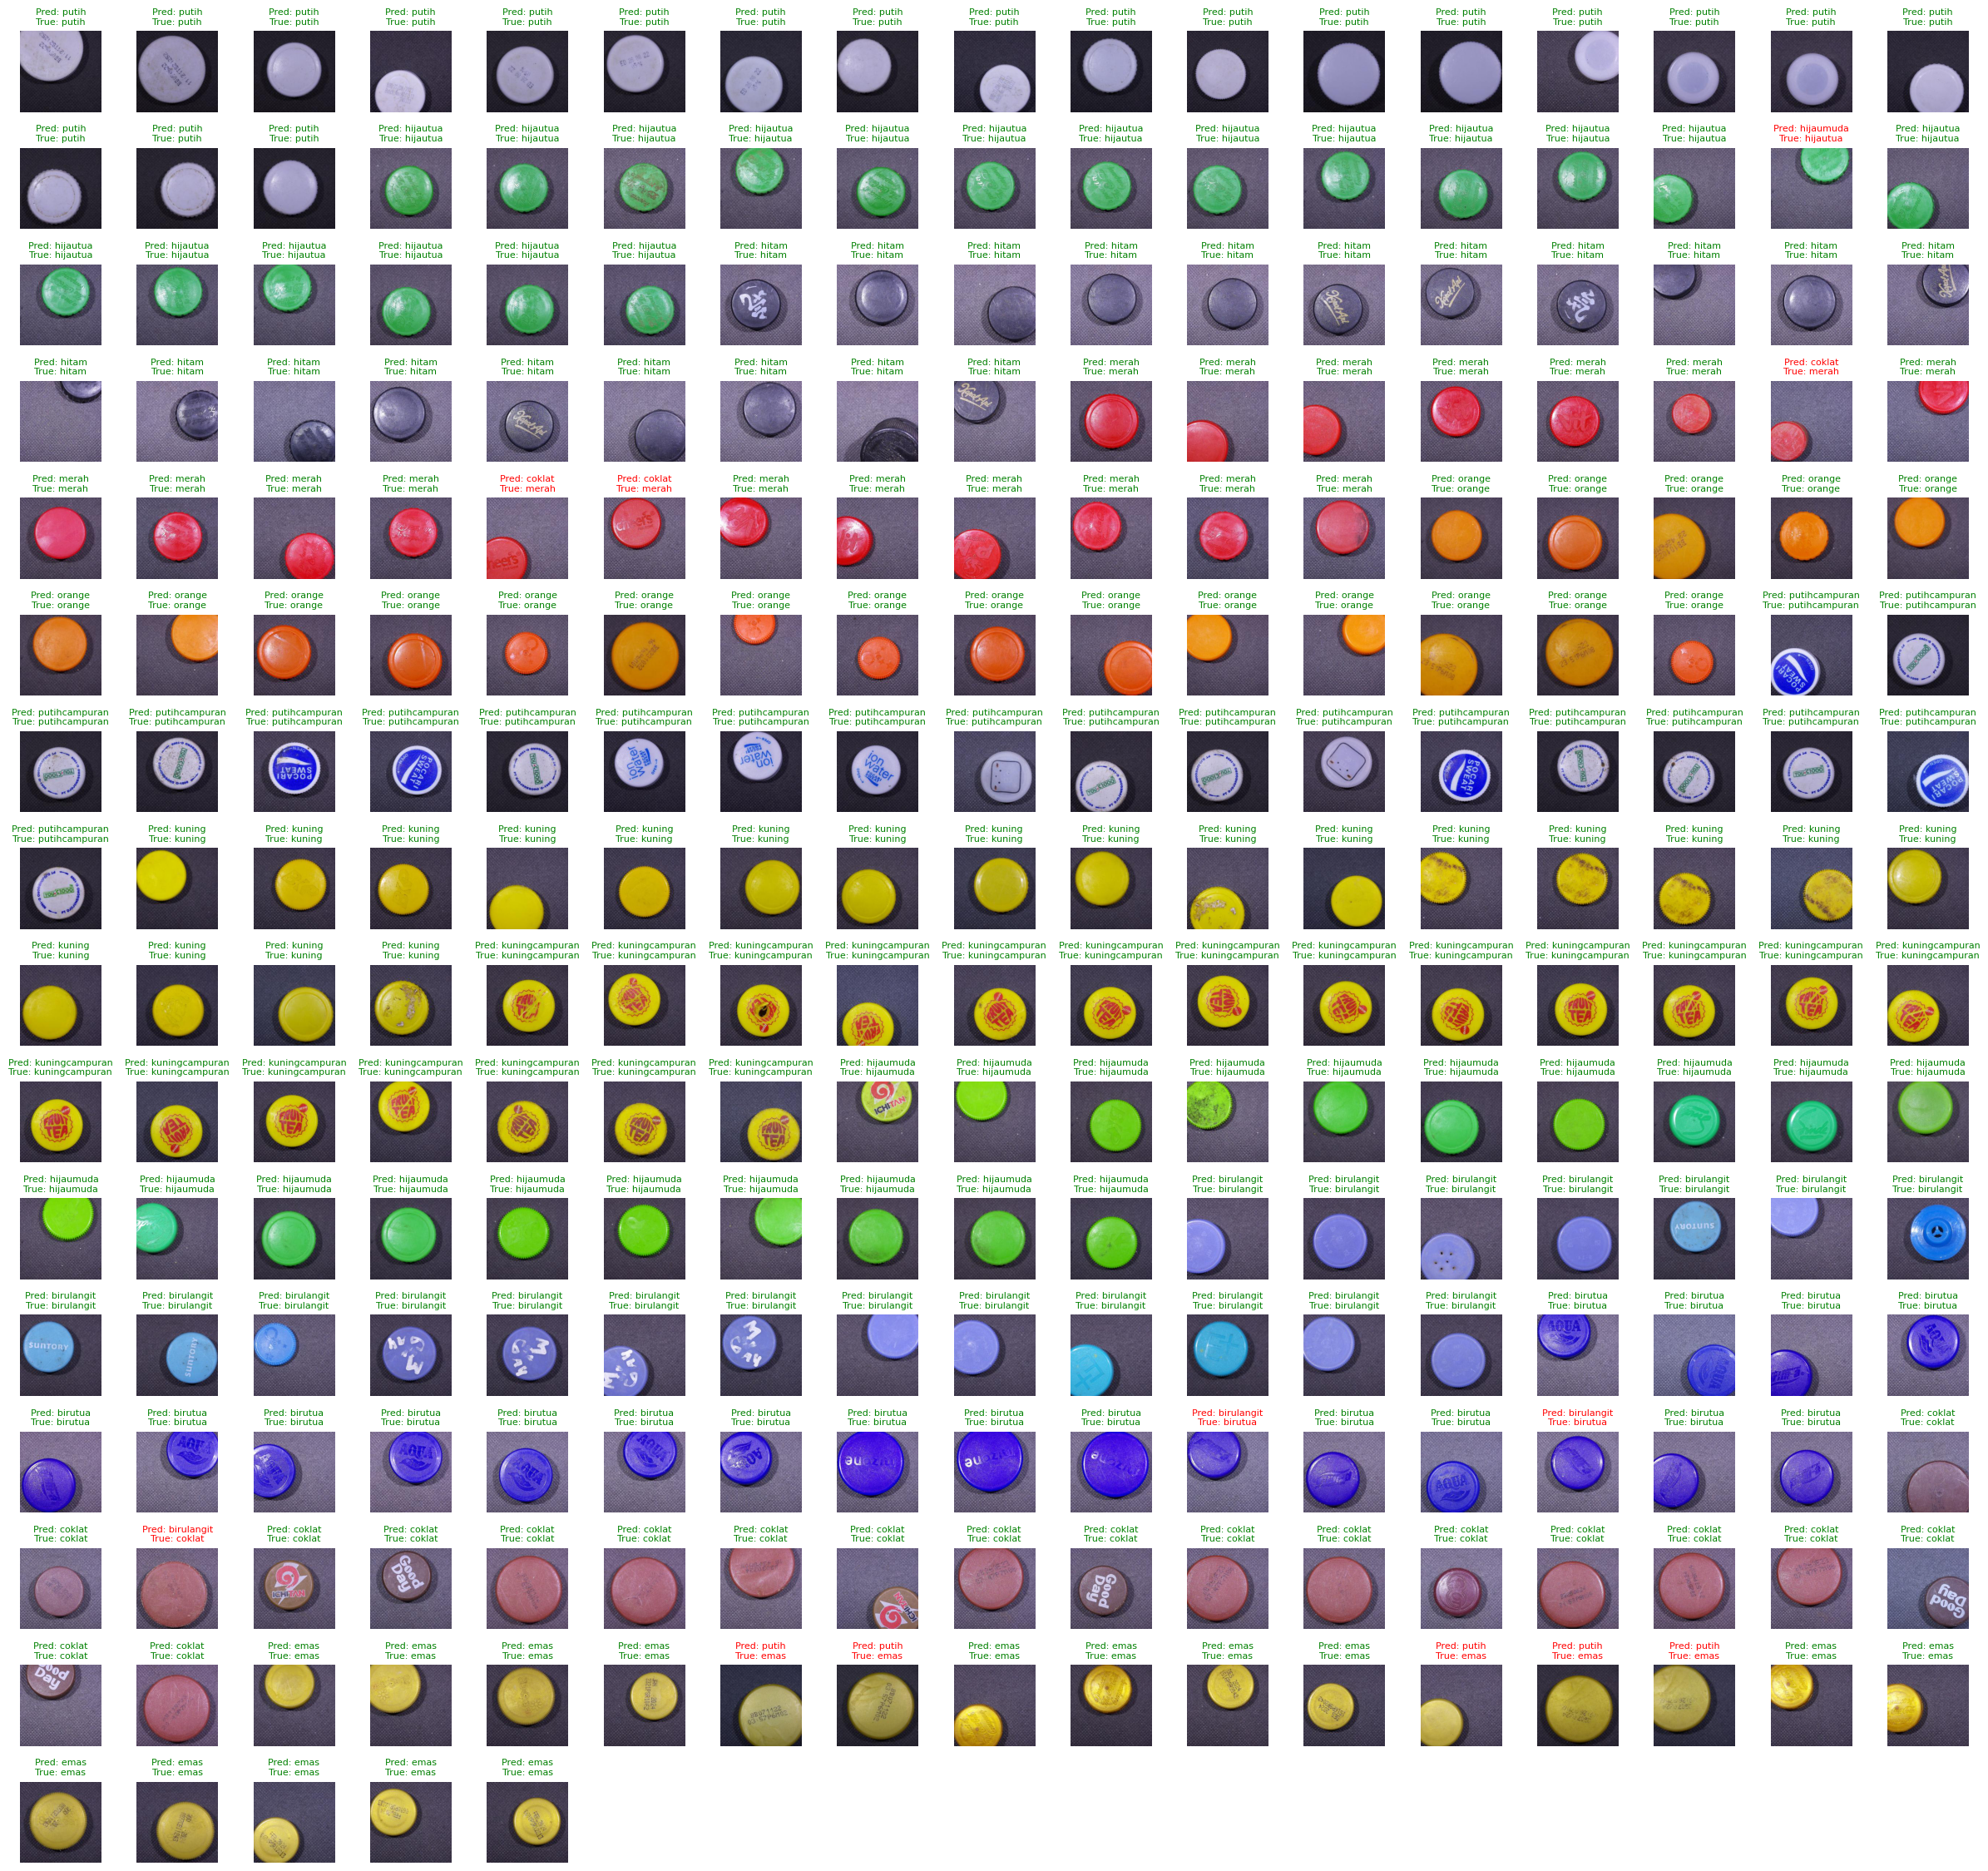

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

model_path = "model_epoch50_32.tflite"
class_file = 'class.txt'

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

# Get input and output details
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Print input/output details for reference
print("Input Shape:", input_details[0]['shape'])
print("Input Type:", input_details[0]['dtype'])
print("Output Shape:", output_details[0]['shape'])
print("Output Type:", output_details[0]['dtype'])

# Read class names from file
with open(class_file, 'r') as f:
    class_names = f.read().splitlines()

# ImageDataGenerator for preprocessing
test_datagen = ImageDataGenerator(rescale=1./255)

# Load test data with batch_size=1
test_generator = test_datagen.flow_from_directory(
    directory='dataset_final/test/',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=1,  # Single image per batch
    class_mode='categorical',
    shuffle=False  # Keep data order consistent
)

# Prepare lists for predictions and actual labels
predicted_classes = []
true_classes = []

# Iterate over test data and make predictions
for i in range(len(test_generator)):
    batch_images, batch_labels = test_generator[i]
    
    # Ensure the input image has the correct shape (1, 224, 224, 3)
    interpreter.set_tensor(input_details[0]['index'], batch_images)
    interpreter.invoke()  # Run inference
    
    # Get prediction output and determine class with highest probability
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predictions = np.argmax(output_data, axis=1)
    
    # Store predictions and true labels
    predicted_classes.extend(predictions)
    true_classes.extend(np.argmax(batch_labels, axis=1))

# Visualization of Predictions
plt.figure(figsize=(24, 24))  # Adjust figure size to fit 12x12 grid

for i in range(min(270, len(predicted_classes))):  # Display up to 144 images in a 12x12 grid
    plt.subplot(17, 17, i + 1)  # Create 12x12 grid
    
    # Load image and display
    img_path = test_generator.filepaths[i]
    img = plt.imread(img_path)
    plt.imshow(img)
    
    # Display true and predicted labels
    true_label = class_names[true_classes[i]]
    predicted_label = class_names[predicted_classes[i]]
    color = "green" if predicted_label == true_label else "red"
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color, fontsize=8)
    plt.axis('off')

plt.tight_layout()
plt.show()


# Hasil Confusion Matriks dan Classification Report

Input Shape: [  1 224 224   3]
Input Type: <class 'numpy.float32'>
Output Shape: [ 1 13]
Output Type: <class 'numpy.float32'>
Found 260 images belonging to 13 classes.
true class : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12

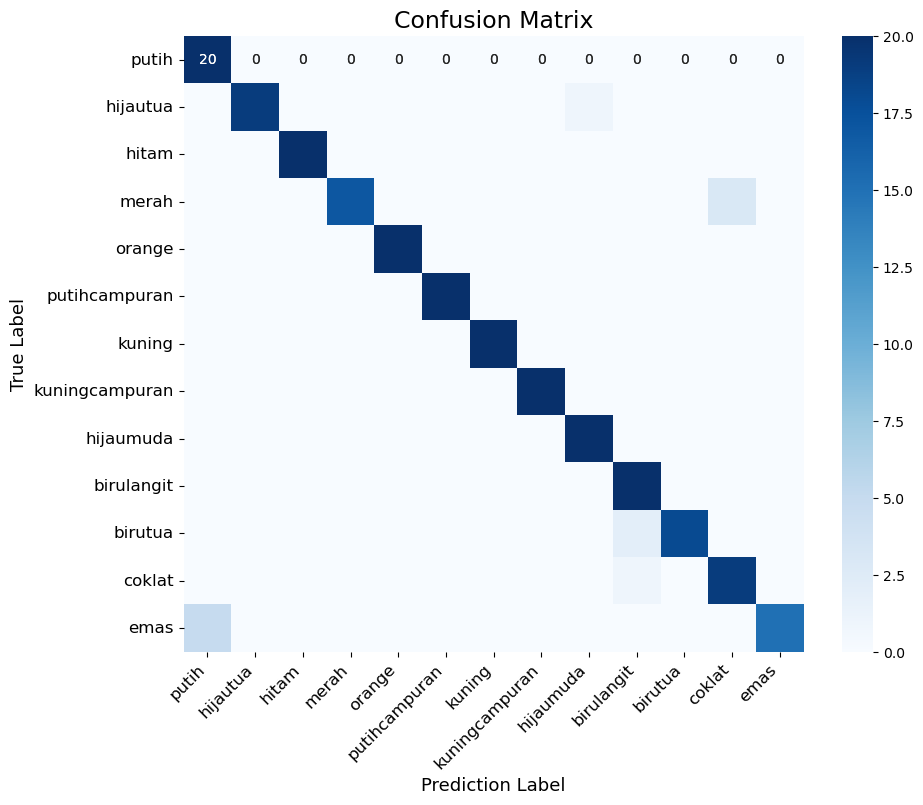

Classification Report:
                 precision    recall  f1-score   support

         putih     0.8000    1.0000    0.8889        20
      hijautua     1.0000    0.9500    0.9744        20
         hitam     1.0000    1.0000    1.0000        20
         merah     1.0000    0.8500    0.9189        20
        orange     1.0000    1.0000    1.0000        20
 putihcampuran     1.0000    1.0000    1.0000        20
        kuning     1.0000    1.0000    1.0000        20
kuningcampuran     1.0000    1.0000    1.0000        20
     hijaumuda     0.9524    1.0000    0.9756        20
    birulangit     0.8696    1.0000    0.9302        20
       birutua     1.0000    0.9000    0.9474        20
        coklat     0.8636    0.9500    0.9048        20
          emas     1.0000    0.7500    0.8571        20

      accuracy                         0.9538       260
     macro avg     0.9604    0.9538    0.9536       260
  weighted avg     0.9604    0.9538    0.9536       260

Accuracy: 0.9538
Clas

In [16]:
# Path ke model .tflite
model_path = "model_epoch50_32.tflite"

# Load model .tflite
interpreter = tf.lite.Interpreter(model_path=model_path)
interpreter.allocate_tensors()

# Dapatkan detail input dan output
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Print informasi input dan output
print("Input Shape:", input_details[0]['shape'])
print("Input Type:", input_details[0]['dtype'])
print("Output Shape:", output_details[0]['shape'])
print("Output Type:", output_details[0]['dtype'])

# Membaca nama kelas dari file class.txt
class_file = 'class.txt'
with open(class_file, 'r') as f:
    class_names = f.read().splitlines()

# Definisikan ImageDataGenerator untuk preprocessing input
test_datagen = ImageDataGenerator(rescale=1./255)  # Normalisasi gambar ke rentang [0, 1]

# Flow dari direktori dengan generator untuk data test
test_generator = test_datagen.flow_from_directory(
    directory='dataset_final/test/',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=1,  # Set batch_size = 1 untuk mengambil satu gambar pada satu waktu
    class_mode='categorical',
    shuffle=False  # Urutan data tetap konsisten saat digunakan dalam generator
)

# List untuk menyimpan hasil prediksi dan label sebenarnya
predicted_classes = []
true_classes = []

# Loop melalui data uji dan lakukan prediksi menggunakan model TensorFlow Lite
for i in range(len(test_generator)):
    batch_images, batch_labels = test_generator[i]

    # Atur tensor input untuk interpreter
    interpreter.set_tensor(input_details[0]['index'], batch_images)

    # Jalankan inferensi
    interpreter.invoke()

    # Ambil hasil output
    output_data = interpreter.get_tensor(output_details[0]['index'])

    # Ambil prediksi kelas dengan probabilitas tertinggi
    predictions = np.argmax(output_data, axis=1)

    # Simpan hasil prediksi dan label sebenarnya
    predicted_classes.extend(predictions)
    true_classes.extend(np.argmax(batch_labels, axis=1))

# Menghitung matriks kebingungan
print("true class :", true_classes)
print("predicted class :", predicted_classes)

cm = confusion_matrix(true_classes, predicted_classes)

# Membuat plot matriks kebingungan
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")


sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues", cbar=False)

# Rotate the x-axis and y-axis labels to ensure they fit and are readable
plt.xticks(rotation=45, ha="right", fontsize=12)  # Rotate x-axis labels for better readability
plt.yticks(rotation=0, fontsize=12)  # Keep y-axis labels horizontal

plt.ylabel('True Label', fontsize=13)
plt.xlabel('Prediction Label', fontsize=13)
plt.title('Confusion Matrix', fontsize=17)
plt.savefig('confusion_matrix_final.png')
plt.show()

# Generate classification report with precision, recall, f1-score (including macro, micro, and weighted averages)
classification_report_str = classification_report(true_classes, predicted_classes, target_names=class_names, digits=4)
print("Classification Report:\n", classification_report_str)

# Save classification report to a text file
with open('classification_report.txt', 'w') as report_file:
    report_file.write(classification_report_str)

# Menghitung metrik evaluasi untuk setiap kelas (tanpa rata-rata makro/mikro untuk presisi, recall, dan F1)
accuracy = accuracy_score(true_classes, predicted_classes)
precision = precision_score(true_classes, predicted_classes, average=None)
recall = recall_score(true_classes, predicted_classes, average=None)
f1 = f1_score(true_classes, predicted_classes, average=None)

# Add macro, micro, and weighted metrics for precision, recall, F1
precision_macro = precision_score(true_classes, predicted_classes, average='macro')
recall_macro = recall_score(true_classes, predicted_classes, average='macro')
f1_macro = f1_score(true_classes, predicted_classes, average='macro')

precision_micro = precision_score(true_classes, predicted_classes, average='micro')
recall_micro = recall_score(true_classes, predicted_classes, average='micro')
f1_micro = f1_score(true_classes, predicted_classes, average='micro')

precision_weighted = precision_score(true_classes, predicted_classes, average='weighted')
recall_weighted = recall_score(true_classes, predicted_classes, average='weighted')
f1_weighted = f1_score(true_classes, predicted_classes, average='weighted')

# Adding metrics to the results dataframe
results = {
    'Class': class_names,
    'Accuracy': [accuracy] * len(class_names),
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

# Create a Pandas DataFrame from the dictionary
df = pd.DataFrame(results)

# Save the DataFrame to a CSV file
df.to_csv('result_cr.csv', index=False)

# Print overall evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
for idx, class_name in enumerate(class_names):
    print(f"Class: {class_name}")
    print(f"  Precision: {precision[idx]:.4f}")
    print(f"  Recall: {recall[idx]:.4f}")
    print(f"  F1 Score: {f1[idx]:.4f}")

# Print macro, micro, and weighted averages
print("\nMacro Average Metrics:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall: {recall_macro:.4f}")
print(f"  F1 Score: {f1_macro:.4f}")

print("\nMicro Average Metrics:")
print(f"  Precision: {precision_micro:.4f}")
print(f"  Recall: {recall_micro:.4f}")
print(f"  F1 Score: {f1_micro:.4f}")

print("\nWeighted Average Metrics:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall: {recall_weighted:.4f}")
print(f"  F1 Score: {f1_weighted:.4f}")